<div style="text-align: center; font-size: 32px;">
<b>PREDIKSI KEBANGKRUTAN PERUSAHAAN ASURANSI DI INDONESIA MENGGUNAKAN ARTIFICIAL NEURAL NETWORKS
</b>
</div>

**Importing Library**

In [ ]:
pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 7.6 MB/s eta 0:00:00


In [2]:

# data manipulation tools
import pandas as pd
import numpy as np
import re

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

# feature selection tools
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


# ignore warnings
import warnings
warnings.filterwarnings('ignore')\

# time module
import time
import itertools

# data preprocessing tools
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

# handing imbalanced datasets
from imblearn.over_sampling import SMOTE

# tools for create ANN arcitecture
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization,LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.utils import to_categorical

# model evaluation tools
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)

# hyperparameter tuning tools
import optuna
from optuna.samplers import TPESampler

# Ranodm State
RANDOM_STATE=42

# ignore warnings
import warnings
warnings.filterwarnings('ignore')



**Importing Dataset**

In [3]:
data = pd.read_csv('D:/Developments/Penelitan Bu Rodhiyyah Mardhiyah/Data Bersih16Param.csv')

**Feature Selection: menghapus bebebrapa fitur yang kurang relevan dengan pemodelan yang akan dilakukan**

In [4]:
data = data.drop(columns=['Sub_Sektor','No','Nama_Perusahaan','Z_Score','Z_Score_X1','Z_Score_X2','Z_Score_X3','Z_Score_X4','Tahun'])
data

,Current_Ratio,Cash_Ratio,DAR,DER,NPM,ROA,ROE,Kepemilikan_Mayoritas,Komisaris_Independen,Insider_Ownership,BoC_Size,BoC_Education,TMT_Size_DK,TMT_Size_DD,TMT_Education_DK,TMT_Education_DD,Total_Asset,Pertumbuhan_Revenue,Label
0,0.52,0.18,0.79,3.85,0.09,0.03,0.13,0.80,2,0.0,4,0,4,5,0,0,31860954000000,-0.2480,Potensi Bangkrut
1,0.53,0.18,0.78,3.61,0.09,0.03,0.15,0.80,2,0.0,4,0,4,5,0,0,35767906000000,0.4761,Potensi Bangkrut
2,0.41,0.15,0.76,3.25,0.10,0.03,0.15,0.95,2,0.0,4,0,4,5,0,0,44937292000000,0.1703,Potensi Bangkrut
3,0.45,0.22,0.76,3.22,0.08,0.02,0.10,0.95,2,0.0,4,0,4,5,0,0,46562563000000,-0.1763,Potensi Bangkrut
4,0.59,0.30,0.76,3.22,0.14,0.04,0.18,0.95,2,0.0,4,0,4,4,0,0,50043024000000,0.2158,Potensi Bangkrut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1166,5.37,0.89,0.23,0.30,0.02,0.00,0.01,1.00,0,0.0,0,0,0,7,0,0,15801971000000,-0.1372,Perusahaan Sehat
1167,5.29,1.05,0.25,0.33,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16149482000000,0.1508,Perusahaan Sehat
1168,4.86,0.99,0.22,0.28,0.01,0.00,0.00,1.00,0,0.0,0,0,0,7,0,0,16468014000000,-0.0317,Perusahaan Sehat
1169,5.77,0.07,0.26,0.35,0.10,0.03,0.04,1.00,0,0.0,0,0,0,7,0,0,16787071000000,0.0580,Perusahaan Sehat


**Splitting Dataset**

In [4]:
X = data.drop(columns=['Label'])
y = data['Label']

In [5]:
# Fit encoder di y sebelum resample
le = LabelEncoder()
y = le.fit_transform(y)

for i, class_label in enumerate(le.classes_):
    print(f"{class_label} -> {i}")

Area abu-abu -> 0
Perusahaan Sehat -> 1
Potensi Bangkrut -> 2


In [6]:
# Optimal Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= RANDOM_STATE,stratify=y)

In [7]:
# Feature Scaling
scaler_standard = StandardScaler()
scaler_robust = RobustScaler()

In [8]:
# Melakukan Scaling pada kolom yang berbeda
# Kolom
cols_robust = ['Current_Ratio', 'Cash_Ratio', 'DER', 'NPM', 'ROA', 'ROE',
               'Kepemilikan_Mayoritas', 'Insider_Ownership', 'BoC_Education',
               'TMT_Education_DD', 'TMT_Education_DK', 'Pertumbuhan_Revenue']

cols_standard = ['DAR', 'Komisaris_Independen', 'BoC_Size', 'TMT_Size_DK',
                 'TMT_Size_DD', 'Total_Asset']


# Fit hanya di training data
X_train_robust_scaled = pd.DataFrame(
    scaler_robust.fit_transform(X_train[cols_robust]),
    columns=cols_robust,
    index=X_train.index
)

X_train_standard_scaled = pd.DataFrame(
    scaler_standard.fit_transform(X_train[cols_standard]),
    columns=cols_standard,
    index=X_train.index
)


# Untuk test data, langsung transform pakai scaler yang sudah fit di train
X_test_robust_scaled = pd.DataFrame(
    scaler_robust.transform(X_test[cols_robust]),
    columns=cols_robust,
    index=X_test.index
)

X_test_standard_scaled = pd.DataFrame(
    scaler_standard.transform(X_test[cols_standard]),
    columns=cols_standard,
    index=X_test.index
)

# Gabungkan kembali menjadi satu DataFrame
X_train_scaled = pd.concat([X_train_robust_scaled, X_train_standard_scaled], axis=1)
X_test_scaled = pd.concat([X_test_robust_scaled, X_test_standard_scaled], axis=1)
X_train = X_train_scaled
X_test = X_test_scaled

In [9]:
# split X_test and y_test into X_test, X_val, y_test, y_val with test_size=0.5
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state= RANDOM_STATE,stratify=y_test)
X_test.shape, X_val.shape, y_test.shape, y_val.shape

((117, 18), (118, 18), (117,), (118,))

In [ ]:
import pickle
import os

# menyimpan objek preprocessing tanpa membuat direktori baru
# 1. Simpan Robust Scaler
with open(os.path.join('robust_scaler.pkl'), 'wb') as file:
    pickle.dump(scaler_robust, file)

# 2. Simpan Standard Scaler
with open(os.path.join('standard_scaler.pkl'), 'wb') as file:
    pickle.dump(scaler_standard, file)



print(f"Objek preprocessing berhasil disimpan")

Objek preprocessing berhasil disimpan


**Handling Imbalance Dataset**

In [ ]:
# Handle Imbalanced Data with SMOTE
smote = SMOTE(random_state= RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# Create DataFrame for train, test, and validation sets
Data_train = pd.DataFrame(X_train_res, columns=X.columns)
Data_train['Label'] = y_train_res

Data_test = pd.DataFrame(X_test, columns=X.columns)
Data_test['Label'] = y_test

Data_val = pd.DataFrame(X_val, columns=X.columns)
Data_val['Label'] = y_val

In [ ]:
# Split X and y for train, test, and validation sets
X_train = Data_train.drop(columns=['Label'])
y_train = Data_train['Label']

X_test = Data_test.drop(columns=['Label'])
y_test = Data_test['Label']

X_val = Data_val.drop(columns=['Label'])
y_val = Data_val['Label']


# **Searching An Architecture Neural Networks**

[I 2025-10-31 02:16:36,665] A new study created in memory with name: no-name-b375587f-58b5-4b44-819b-a90f6aac284f
[I 2025-10-31 02:16:43,151] Trial 0 finished with value: 0.8389830589294434 and parameters: {'n_layers': 3, 'units_0': 245, 'activation_0': 'leaky_relu', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 216, 'activation_1': 'softmax', 'use_dropout_1': False, 'use_batchnorm_1': False, 'units_2': 89, 'activation_2': 'tanh', 'use_dropout_2': True, 'dropout_rate_2': 0.12602063719411183, 'use_batchnorm_2': False, 'lr': 0.004138040112561018, 'batch_size': 64}. Best is trial 0 with value: 0.8389830589294434.
[I 2025-10-31 02:16:52,486] Trial 1 finished with value: 0.8135592937469482 and parameters: {'n_layers': 3, 'units_0': 59, 'activation_0': 'selu', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 202, 'activation_1': 'relu', 'use_dropout_1': False, 'use_batchnorm_1': True, 'units_2': 170, 'activation_2': 'softmax', 'use_dropout_2': True, 'dropout_rate_2

Best trial: {'n_layers': 3, 'units_0': 155, 'activation_0': 'tanh', 'use_dropout_0': True, 'dropout_rate_0': 0.30094591528481707, 'use_batchnorm_0': True, 'units_1': 218, 'activation_1': 'relu', 'use_dropout_1': False, 'use_batchnorm_1': True, 'units_2': 75, 'activation_2': 'leaky_relu', 'use_dropout_2': False, 'use_batchnorm_2': False, 'lr': 0.0020901259420713974, 'batch_size': 32}
Epoch 1/200
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5655 - loss: 1.0880
Epoch 1: val_accuracy improved from -inf to 0.72034, saving model to best_model_final.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5710 - loss: 1.0731 - val_accuracy: 0.7203 - val_loss: 0.7533 - learning_rate: 0.0021
Epoch 2/200
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7456 - loss: 0.6418
Epoch 2: val_accuracy improved from 0.72034 to 0.72881, saving model to best_model_final.keras
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7452 - loss: 0.6425 - val_accuracy: 0.7288 - val_loss: 0.6712 - 

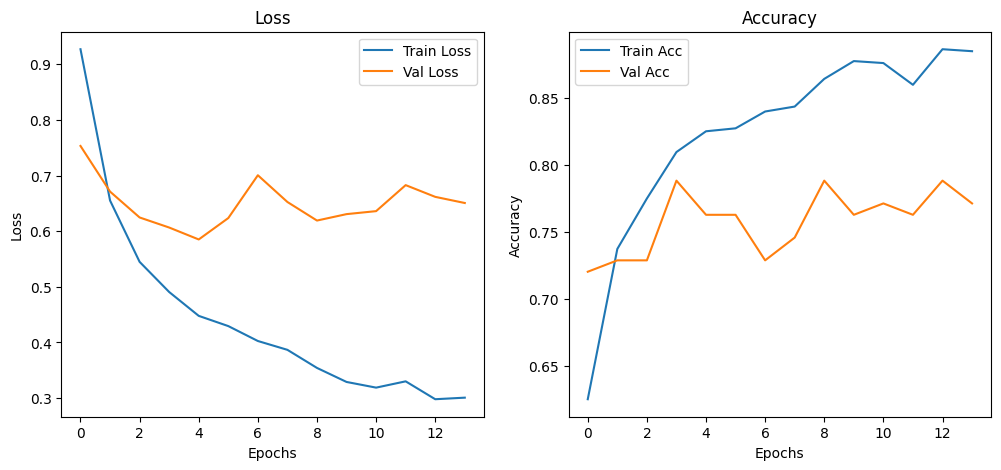

In [ ]:
import optuna
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# ===============================
# 🔒 Seed untuk reproducibility
# ===============================
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# ===============================
# 🔑 One-hot encoding label
# ===============================
num_classes = len(set(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

# ===============================
# 🎯 Objective function Optuna
# ===============================
def objective(trial):
    model = Sequential()

    # Jumlah hidden layer (2–5)
    n_layers = trial.suggest_int("n_layers", 2, 5)

    # Hidden layer pertama
    prev_units = trial.suggest_int("units_0", 32, 256)
    activation = trial.suggest_categorical("activation_0", ["relu", "tanh", "selu",'sigmoid','softmax','leaky_relu'])
    model.add(Dense(prev_units, activation=activation, input_dim=X_train.shape[1]))

    # Opsi Dropout & BatchNorm di layer pertama
    if trial.suggest_categorical("use_dropout_0", [True, False]):
        rate = trial.suggest_float("dropout_rate_0", 0.1, 0.5)
        model.add(Dropout(rate))
    if trial.suggest_categorical("use_batchnorm_0", [True, False]):
        model.add(BatchNormalization())

    # Hidden layer berikutnya
    for i in range(1, n_layers):
        min_units, max_units = 16, 256
        if i == n_layers - 1:
            max_units = prev_units  # constraint: tidak lebih besar dari layer sebelumnya
        units = trial.suggest_int(f"units_{i}", min_units, max_units)
        activation = trial.suggest_categorical(f"activation_{i}", ["relu", "tanh", "selu",'sigmoid','softmax','leaky_relu'])
        model.add(Dense(units, activation=activation))
        prev_units = units

        # Opsi Dropout & BatchNorm
        if trial.suggest_categorical(f"use_dropout_{i}", [True, False]):
            rate = trial.suggest_float(f"dropout_rate_{i}", 0.1, 0.5)
            model.add(Dropout(rate))
        if trial.suggest_categorical(f"use_batchnorm_{i}", [True, False]):
            model.add(BatchNormalization())

    # Output layer
    model.add(Dense(num_classes, activation="softmax"))

    # Optimizer
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer,
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=0),
        ModelCheckpoint("best_model_optuna.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, verbose=0)
    ]

    # Training
    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=100,  # cukup 100 karena ada early stopping
        batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
        callbacks=callbacks,
        verbose=0
    )

    return max(history.history["val_accuracy"])


# ===============================
# 🚀 Jalankan Optuna
# ===============================
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=150)  # bisa ditingkatkan sesuai kebutuhan

print("Best trial:", study.best_trial.params)


# ===============================
# 🔁 Retrain model dengan best params
# ===============================
best_params = study.best_trial.params
model = Sequential()

# Hidden layer pertama
prev_units = best_params["units_0"]
activation = best_params["activation_0"]
model.add(Dense(prev_units, activation=activation, input_dim=X_train.shape[1]))

if best_params.get("use_dropout_0", False):
    model.add(Dropout(best_params["dropout_rate_0"]))
if best_params.get("use_batchnorm_0", False):
    model.add(BatchNormalization())

# Hidden layer berikutnya
for i in range(1, best_params["n_layers"]):
    max_units = prev_units if i == best_params["n_layers"] - 1 else 256
    units = best_params[f"units_{i}"]
    activation = best_params[f"activation_{i}"]
    model.add(Dense(units, activation=activation))
    prev_units = units

    if best_params.get(f"use_dropout_{i}", False):
        model.add(Dropout(best_params[f"dropout_rate_{i}"]))
    if best_params.get(f"use_batchnorm_{i}", False):
        model.add(BatchNormalization())

# Output layer
model.add(Dense(num_classes, activation="softmax"))

optimizer = Adam(learning_rate=best_params["lr"])
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model_final.keras", monitor="val_accuracy", save_best_only=True, mode="max", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, verbose=1)
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=200,
    batch_size=best_params["batch_size"],
    callbacks=callbacks,
    verbose=1
)

# ===============================
# 📊 Plot Loss & Accuracy
# ===============================
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
model.summary()

Model: "sequential_150"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_605 (Dense)               │ (None, 155)            │         2,945 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_162 (Dropout)           │ (None, 155)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_253         │ (None, 155)            │           620 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_606 (Dense)               │ (None, 218)            │        34,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_254         │ (None, 218)            │           872 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_607 (Dense)               │ (None, 75)             │        16,425 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_608 (Dense)               │ (None, 3)              │           228 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,804 (639.86 KB)

 Trainable params: 54,352 (212.31 KB)

 Non-trainable params: 746 (2.91 KB)

 Optimizer params: 108,706 (424.64 KB)

{'n_layers': 4, 'units_0': 101, 'activation_0': 'tanh', 'use_dropout_0': False, 'use_batchnorm_0': False, 'units_1': 67, 'activation_1': 'selu', 'use_dropout_1': True, 'dropout_rate_1': 0.17155679861891207, 'use_batchnorm_1': True, 'units_2': 146, 'activation_2': 'selu', 'use_dropout_2': False, 'use_batchnorm_2': False, 'units_3': 37, 'activation_3': 'leaky_relu', 'use_dropout_3': False, 'use_batchnorm_3': False, 'lr': 0.0018994610036140445, 'batch_size': 32}
Epoch 1/200

In [ ]:
# Arsitektur layer tetap
ARCHITECTURE = [
    {"units": 101, "activation": "tanh"},
    {"units": 67, "activation": "selu"},
    {"units": 146, "activation": "selu"},
    {"units": 37, "activation": "leaky_relu"}
]

def create_model(trial):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))  # sesuaikan input dim

    for i, layer in enumerate(ARCHITECTURE):
        # Regularisasi
        reg_type = trial.suggest_categorical(f"reg_{i}", ["l1", "l2", None])
        reg_strength = trial.suggest_float(f"reg_strength_{i}", 1e-5, 1e-2, log=True)

        if reg_type == "l1":
            kernel_reg = regularizers.l1(reg_strength)
        elif reg_type == "l2":
            kernel_reg = regularizers.l2(reg_strength)
        else:
            kernel_reg = None

        model.add(Dense(layer["units"], activation=layer["activation"], kernel_regularizer=kernel_reg))

        # Dropout
        if trial.suggest_categorical(f"use_dropout_{i}", [True, False]):
            dropout_rate = trial.suggest_float(f"dropout_rate_{i}", 0.1, 0.5)
            model.add(Dropout(dropout_rate))

        # BatchNormalization
        if trial.suggest_categorical(f"use_batchnorm_{i}", [True, False]):
            model.add(BatchNormalization())

    # Output layer
    model.add(Dense(3, activation="softmax"))

    # Optimizer & learning rate
    optimizer = Adam(learning_rate=0.0028926853954885133)
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    return model

def objective(trial):
    model = create_model(trial)

    # Callbacks
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        verbose=0,
        callbacks=callbacks
    )

    val_acc = max(history.history["val_accuracy"])
    return val_acc

# Jalankan Optuna
study = optuna.create_study(direction="maximize", study_name="Neural Network Tuning with Fixed Architecture", sampler=TPESampler(constant_liar=True))
study.optimize(objective, n_trials=100)  # bisa ditingkatkan sesuai kebutuhan

print("Best trial:")
print(study.best_trial.params)


[I 2025-10-31 02:40:27,705] A new study created in memory with name: Neural Network Tuning with Fixed Architecture
[I 2025-10-31 02:40:35,295] Trial 0 finished with value: 0.7881355881690979 and parameters: {'reg_0': 'l2', 'reg_strength_0': 3.759851391119611e-05, 'use_dropout_0': False, 'use_batchnorm_0': True, 'reg_1': 'l2', 'reg_strength_1': 0.0038080042134712323, 'use_dropout_1': False, 'use_batchnorm_1': False, 'reg_2': 'l1', 'reg_strength_2': 9.15456785990318e-05, 'use_dropout_2': False, 'use_batchnorm_2': False, 'reg_3': 'l1', 'reg_strength_3': 0.008284356352415522, 'use_dropout_3': True, 'dropout_rate_3': 0.43894547426851827, 'use_batchnorm_3': True}. Best is trial 0 with value: 0.7881355881690979.
[I 2025-10-31 02:40:40,402] Trial 1 finished with value: 0.7542372941970825 and parameters: {'reg_0': 'l2', 'reg_strength_0': 0.002736455962362151, 'use_dropout_0': True, 'dropout_rate_0': 0.4622867544605259, 'use_batchnorm_0': False, 'reg_1': None, 'reg_strength_1': 0.000244210525986

Best trial:
{'reg_0': 'l1', 'reg_strength_0': 3.487233791656298e-05, 'use_dropout_0': False, 'use_batchnorm_0': True, 'reg_1': 'l2', 'reg_strength_1': 8.405918654990778e-05, 'use_dropout_1': False, 'use_batchnorm_1': False, 'reg_2': 'l1', 'reg_strength_2': 0.0001765508503575578, 'use_dropout_2': True, 'dropout_rate_2': 0.13548011079180863, 'use_batchnorm_2': False, 'reg_3': 'l2', 'reg_strength_3': 0.00021317978034334132, 'use_dropout_3': True, 'dropout_rate_3': 0.4181052796607785, 'use_batchnorm_3': False}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras import regularizers

def build_best_model(input_dim, params):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    # Definisi layer berdasarkan hasil tuning (units & activation fixed)
    layers_config = [
        {"units": 128, "activation": "sigmoid"},
        {"units": 96,  "activation": "sigmoid"},
        {"units": 96,  "activation": "leaky_relu"},
        {"units": 224, "activation": "softmax"}
    ]

    for i, cfg in enumerate(layers_config):
        # --- Regularizer ---
        reg_type = params.get(f"reg_{i}")
        reg_strength = params.get(f"reg_strength_{i}", 1e-5)

        kernel_reg = None
        if reg_type == "l1":
            kernel_reg = regularizers.l1(reg_strength)
        elif reg_type == "l2":
            kernel_reg = regularizers.l2(reg_strength)

        # --- Dense Layer ---
        model.add(Dense(
            cfg["units"],
            activation=cfg["activation"],
            kernel_regularizer=kernel_reg
        ))

        # --- Dropout ---
        if params.get(f"use_dropout_{i}", False):
            rate = params.get(f"dropout_rate_{i}", 0.3)
            model.add(Dropout(rate))

        # --- BatchNormalization ---
        if params.get(f"use_batchnorm_{i}", False):
            model.add(BatchNormalization())

    # Output layer sesuai jumlah kelas (3 di contohmu)
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ==== Contoh panggilan ====
params = {
    'reg_0': 'l2', 'reg_strength_0': 1.924960830847294e-05, 'use_dropout_0': False, 'use_batchnorm_0': True,
    'reg_1': 'l2', 'reg_strength_1': 3.2449814511088114e-05, 'use_dropout_1': True, 'dropout_rate_1': 0.13135855464181728, 'use_batchnorm_1': False,
    'reg_2': 'l2', 'reg_strength_2': 0.00380654936732092, 'use_dropout_2': True, 'dropout_rate_2': 0.4628112882903003, 'use_batchnorm_2': False,
    'reg_3': 'l2', 'reg_strength_3': 0.0009208726241388853, 'use_dropout_3': False, 'use_batchnorm_3': True
}

model = build_best_model(X_train.shape[1], params)
model.summary()


Model: "sequential_251"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1109 (Dense)              │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_452         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1110 (Dense)              │ (None, 96)             │        12,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_356 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1111 (Dense)              │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_357 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1112 (Dense)              │ (None, 224)            │        21,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_453         │ (None, 224)            │           896 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1113 (Dense)              │ (None, 3)              │           675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,939 (187.26 KB)

 Trainable params: 47,235 (184.51 KB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/100
35/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4329 - loss: 1.5290
Epoch 1: val_accuracy improved from -inf to 0.33051, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4430 - loss: 1.5106 - val_accuracy: 0.3305 - val_loss: 1.4379
Epoch 2/100
35/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6219 - loss: 1.1528
Epoch 2: val_accuracy did not improve from 0.33051
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6293 - loss: 1.1369 - val_accuracy: 0.1864 - val_loss: 1.4048
Epoch 3/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7079 - loss: 0.9244
Epoch 3: val_accuracy did not improve from 0.33051
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7089 - loss: 0.9223 - val_accuracy: 0.1864 - val_loss: 1.3909
Epoch 4/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7530 - loss: 0.8390
Epoch 4: val_accuracy did not improve from 0.33051
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7521 - loss: 0.8379 - val_accuracy: 0.1864 - val_loss: 1.3454
Epoch 5/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7369 - loss: 0.8027
Epoch 5: val_accuracy did not improve from 0.3

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7883 - loss: 0.6605 - val_accuracy: 0.4153 - val_loss: 1.0851
Epoch 10/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7831 - loss: 0.6462
Epoch 10: val_accuracy improved from 0.41525 to 0.59322, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7828 - loss: 0.6465 - val_accuracy: 0.5932 - val_loss: 0.9906
Epoch 11/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7745 - loss: 0.6476
Epoch 11: val_accuracy improved from 0.59322 to 0.60169, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7746 - loss: 0.6481 - val_accuracy: 0.6017 - val_loss: 0.9637
Epoch 12/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7658 - loss: 0.6246
Epoch 12: val_accuracy improved from 0.60169 to 0.74576, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7662 - loss: 0.6250 - val_accuracy: 0.7458 - val_loss: 0.8556
Epoch 13/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7902 - loss: 0.6079
Epoch 13: val_accuracy improved from 0.74576 to 0.77966, saving model to best_model.h5


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7901 - loss: 0.6091 - val_accuracy: 0.7797 - val_loss: 0.7696
Epoch 14/100
36/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7877 - loss: 0.6080
Epoch 14: val_accuracy did not improve from 0.77966
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7871 - loss: 0.6085 - val_accuracy: 0.7542 - val_loss: 0.7336
Epoch 15/100
36/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7748 - loss: 0.5928
Epoch 15: val_accuracy did not improve from 0.77966
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7762 - loss: 0.5934 - val_accuracy: 0.7627 - val_loss: 0.6757
Epoch 16/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8041 - loss: 0.5745
Epoch 16: val_accuracy did not improve from 0.77966
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8043 - loss: 0.5757 - val_accuracy: 0.7797 - val_loss: 0.6738
Epoch 17/100
37/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7873 - loss: 0.5763
Epoch 17: val_accuracy did not improve f

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8321 - loss: 0.4738 - val_accuracy: 0.7966 - val_loss: 0.6034
Epoch 35/100
32/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8250 - loss: 0.4854
Epoch 35: val_accuracy did not improve from 0.79661
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8262 - loss: 0.4869 - val_accuracy: 0.7712 - val_loss: 0.6211
Epoch 36/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8408 - loss: 0.4474
Epoch 36: val_accuracy did not improve from 0.79661
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8407 - loss: 0.4484 - val_accuracy: 0.7458 - val_loss: 0.6171
Epoch 37/100
36/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8512 - loss: 0.4583
Epoch 37: val_accuracy did not improve from 0.79661
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8509 - loss: 0.4583 - val_accuracy: 0.7712 - val_loss: 0.6090
Epoch 38/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8287 - loss: 0.4634
Epoch 38: val_accuracy did not improve f

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8564 - loss: 0.4401 - val_accuracy: 0.8136 - val_loss: 0.6051
Epoch 44/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8578 - loss: 0.4354
Epoch 44: val_accuracy did not improve from 0.81356
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8579 - loss: 0.4347 - val_accuracy: 0.7627 - val_loss: 0.6158
Epoch 45/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8584 - loss: 0.4253
Epoch 45: val_accuracy did not improve from 0.81356
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8591 - loss: 0.4247 - val_accuracy: 0.7881 - val_loss: 0.6023
Epoch 46/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8599 - loss: 0.4196
Epoch 46: val_accuracy did not improve from 0.81356
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8602 - loss: 0.4191 - val_accuracy: 0.7881 - val_loss: 0.6034
Epoch 47/100
36/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8551 - loss: 0.4250
Epoch 47: val_accuracy did not improve f

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9274 - loss: 0.2687 - val_accuracy: 0.8220 - val_loss: 0.6207
Epoch 93/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9155 - loss: 0.2707
Epoch 93: val_accuracy did not improve from 0.82203
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9157 - loss: 0.2711 - val_accuracy: 0.8051 - val_loss: 0.6795
Epoch 94/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9351 - loss: 0.2499
Epoch 94: val_accuracy did not improve from 0.82203
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9342 - loss: 0.2516 - val_accuracy: 0.8136 - val_loss: 0.6945
Epoch 95/100
38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9247 - loss: 0.2703
Epoch 95: val_accuracy did not improve from 0.82203
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9259 - loss: 0.2677 - val_accuracy: 0.7881 - val_loss: 0.6972
Epoch 96/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9218 - loss: 0.2742
Epoch 96: val_accuracy did not improve f

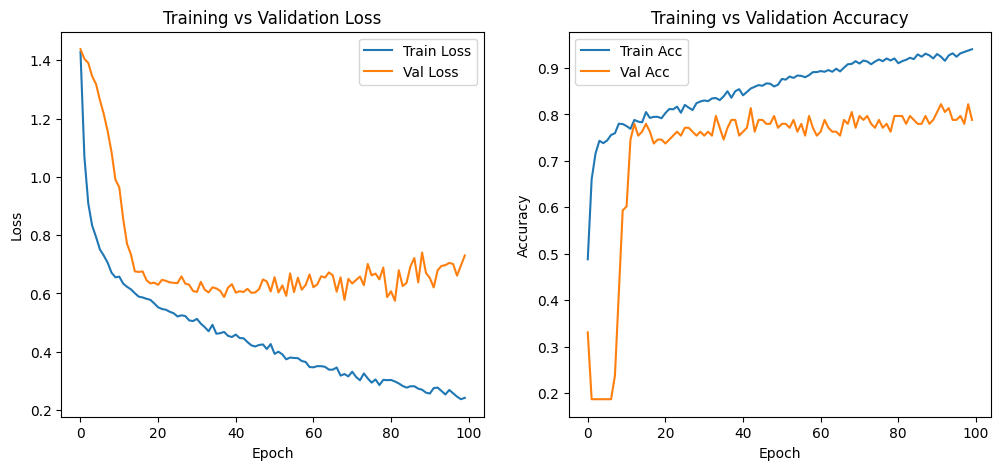

In [ ]:
# Callback untuk simpan model terbaik berdasarkan val_loss
checkpoint = ModelCheckpoint(
    "best_model.h5",        # nama file hasil simpan
    monitor="val_accuracy",     # metric yang dipantau
    mode="max",             # karena accuracy lebih besar lebih baik
    save_best_only=True,    # hanya simpan model terbaik
    verbose=1
)

# Callback EarlyStopping (opsional, biar training berhenti kalau sudah mentok)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,           # hentikan training jika 20 epoch tidak ada peningkatan
    restore_best_weights=True,
    verbose=1
)

# Training dengan callback
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1,
    callbacks=[checkpoint]   # tambahkan callback di sini
)

# Simpan history
np.save("history.npy", history.history)

# Evaluasi di test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🔎 Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Plot training vs validation loss & accuracy
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


In [ ]:
from tensorflow.keras.models import load_model

# Load model dari file .h5
model = load_model("best_model.h5")

Test Accuracy: 0.7863
Test Loss: 0.7026
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


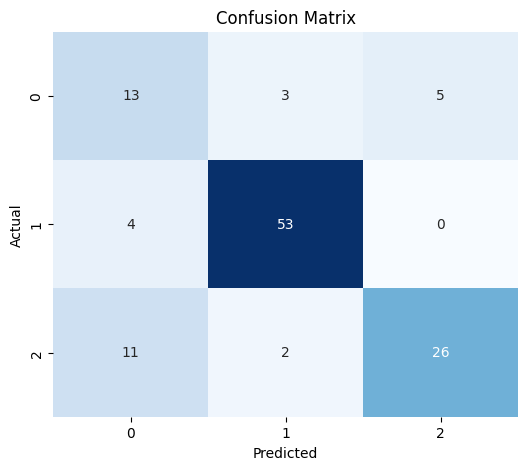


Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.62      0.53        21
           1       0.91      0.93      0.92        57
           2       0.84      0.67      0.74        39

    accuracy                           0.79       117
   macro avg       0.74      0.74      0.73       117
weighted avg       0.81      0.79      0.79       117



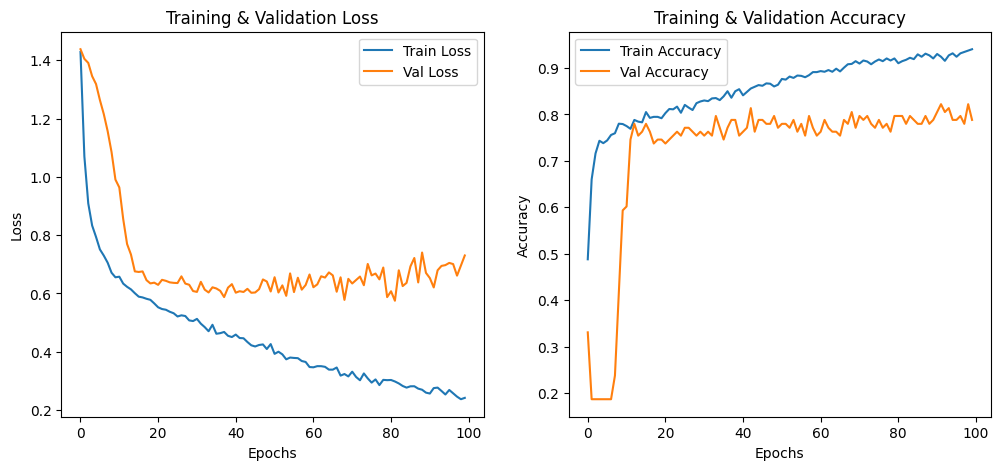

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# 1. Load model
model = load_model("best_model.h5")

# 2. Evaluasi model di test set
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Loss: {loss:.4f}")

# 3. Prediksi kelas
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# 4. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 5. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 6. (Opsional) Plot Training History kalau kamu masih punya 'history'
# Misalnya kamu sebelumnya menyimpan history ke file .npy
# np.save("history.npy", history.history)
# lalu load ulang:
try:
    history_dict = np.load("history.npy", allow_pickle=True).item()

    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history_dict["loss"], label="Train Loss")
    plt.plot(history_dict["val_loss"], label="Val Loss")
    plt.title("Training & Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history_dict["accuracy"], label="Train Accuracy")
    plt.plot(history_dict["val_accuracy"], label="Val Accuracy")
    plt.title("Training & Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()
except:
    print("⚠️ History training tidak ditemukan. Simpan dulu saat training pakai np.save('history.npy', history.history)")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test Accuracy: 0.7863

Classification Report:
                  precision    recall  f1-score   support

    Area abu-abu       0.46      0.62      0.53        21
Perusahaan Sehat       0.91      0.93      0.92        57
Potensi Bangkrut       0.84      0.67      0.74        39

        accuracy                           0.79       117
       macro avg       0.74      0.74      0.73       117
    weighted avg       0.81      0.79      0.79       117

Kelas Area abu-abu -> Precision: 0.4643, Recall: 0.6190, F1-score: 0.5306
Kelas Perusahaan Sehat -> Precision: 0.9138, Recall: 0.9298, F1-score: 0.9217
Kelas Potensi Bangkrut -> Precision: 0.8387, Recall: 0.6667, F1-score: 0.7429

Macro Avg -> Precision: 0.7389, Recall: 0.7385, F1-score: 0.7317
Weighted Avg -> Precision: 0.8081, Recall: 0.7863, F1-score: 0.7919


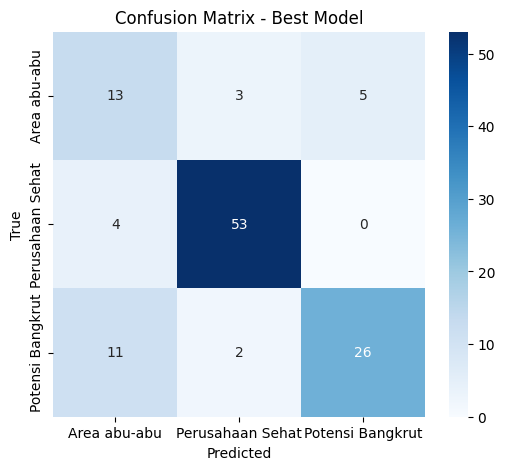

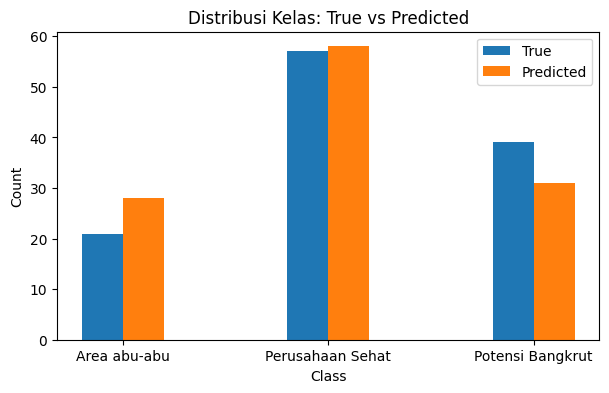

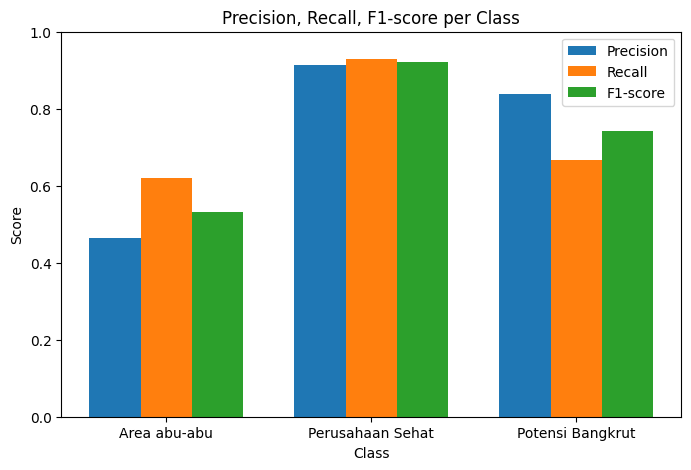

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 🔹 Prediksi di test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🔹 Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f}")

# 🔹 Ambil label asli dari LabelEncoder
class_names = le.classes_

# 🔹 Classification report (dict & print) pakai target_names
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# 🔹 Tampilkan precision, recall, f1 tiap kelas
for label in class_names:
    print(f"Kelas {label} -> Precision: {report[label]['precision']:.4f}, "
          f"Recall: {report[label]['recall']:.4f}, "
          f"F1-score: {report[label]['f1-score']:.4f}")

print("\nMacro Avg -> "
      f"Precision: {report['macro avg']['precision']:.4f}, "
      f"Recall: {report['macro avg']['recall']:.4f}, "
      f"F1-score: {report['macro avg']['f1-score']:.4f}")

print("Weighted Avg -> "
      f"Precision: {report['weighted avg']['precision']:.4f}, "
      f"Recall: {report['weighted avg']['recall']:.4f}, "
      f"F1-score: {report['weighted avg']['f1-score']:.4f}")

# 🔹 Confusion Matrix dengan label asli
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best Model")
plt.show()

# 🔹 Plot distribusi prediksi vs ground truth
plt.figure(figsize=(7,4))
plt.hist([y_test, y_pred], bins=np.arange(len(class_names)+1)-0.5,
         label=["True", "Predicted"], rwidth=0.4)
plt.xticks(np.arange(len(class_names)), class_names)
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend()
plt.title("Distribusi Kelas: True vs Predicted")
plt.show()

# 🔹 Bar chart precision, recall, f1-score per kelas
labels = class_names
precision = [report[l]['precision'] for l in labels]
recall = [report[l]['recall'] for l in labels]
f1 = [report[l]['f1-score'] for l in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Precision, Recall, F1-score per Class")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 🔹 Accuracy
acc = accuracy_score(y_test, y_pred)

# 🔹 Precision, Recall, F1-score (weighted)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("="*50)
print("📊 Evaluation Metrics - Keseluruhan Model")
print("="*50)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")


📊 Evaluation Metrics - Keseluruhan Model
Accuracy : 0.7863
Precision: 0.8081
Recall   : 0.7863
F1-score : 0.7919



================= ANN =================
Accuracy : 0.7863247863247863
Precision: 0.7389294983844484
Recall   : 0.7385129490392649
F1-Score : 0.7317361727299616

Classification Report:

              precision    recall  f1-score   support

           0       0.46      0.62      0.53        21
           1       0.91      0.93      0.92        57
           2       0.84      0.67      0.74        39

    accuracy                           0.79       117
   macro avg       0.74      0.74      0.73       117
weighted avg       0.81      0.79      0.79       117



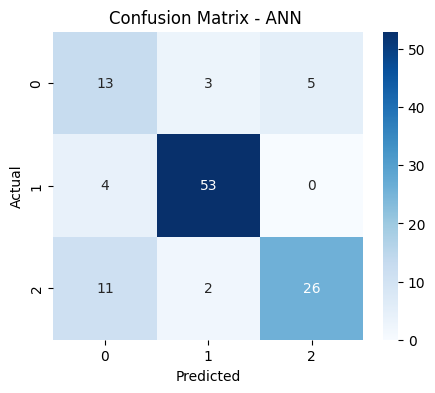

In [ ]:
print(f"\n================= ANN =================")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall   :", recall_score(y_test, y_pred, average='macro'))
print("F1-Score :", f1_score(y_test, y_pred, average='macro'))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - ANN ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

---

# **Prediksi Data**

In [1]:
import pandas as pd
import numpy as np
import pickle
from tensorflow.keras.models import load_model

# --- 0. KONFIGURASI DAN PEMUATAN OBJEK ---

# Definisi SEMUA Kolom Model
ALL_MODEL_COLS = [
    'Current_Ratio', 'Cash_Ratio', 'DAR', 'DER', 'NPM', 'ROA', 'ROE',
       'Kepemilikan_Mayoritas', 'Komisaris_Independen', 'Insider_Ownership',
       'BoC_Size', 'BoC_Education', 'TMT_Size_DK', 'TMT_Size_DD',
       'TMT_Education_DK', 'TMT_Education_DD', 'Total_Asset',
       'Pertumbuhan_Revenue'
]

# Definisi Pembagian Kolom untuk Scaling
cols_robust = ['Current_Ratio', 'Cash_Ratio', 'DER', 'NPM', 'ROA', 'ROE',
               'Kepemilikan_Mayoritas', 'Insider_Ownership', 'BoC_Education',
               'TMT_Education_DD', 'TMT_Education_DK', 'Pertumbuhan_Revenue']
cols_standard = ['DAR', 'Komisaris_Independen', 'BoC_Size', 'TMT_Size_DK',
                 'TMT_Size_DD', 'Total_Asset']

# Definisi Label Kelas
CLASS_LABELS = {
    0: "Area abu-abu",
    1: "Perusahaan Sehat",
    2: "Potensi Bangkrut"
}

# Validasi kolom
if sorted(ALL_MODEL_COLS) != sorted(cols_robust + cols_standard):
    print("❌ ERROR KRITIS: Daftar ALL_MODEL_COLS tidak sesuai dengan gabungan cols_robust dan cols_standard.")
    exit()

try:
    # Load Model ANN
    model = load_model("best_model.h5")
    print(" Model ANN (best_model.h5) berhasil dimuat.")
    
    # Load Scaler
    with open('robust_scaler.pkl', 'rb') as file:
        scaler_robust = pickle.load(file)
    with open('standard_scaler.pkl', 'rb') as file:
        scaler_standard = pickle.load(file)
    print(" Scaler (robust & standard) berhasil dimuat.")

except FileNotFoundError as e:
    print(f"❌ ERROR: File tidak ditemukan - {e}. Pastikan semua file (.h5 dan .pkl) ada di lokasi yang benar.")
    exit()


# --- 1. FUNGSI INPUT INTERAKTIF ---

def get_interactive_user_input(columns):
    """Meminta input dari user untuk setiap kolom secara interaktif."""
    
    print("\n=======================================================")
    print("       INPUT NILAI FITUR UNTUK PREDIKSI KELAS")
    print("=======================================================")
    
    user_data = {}
    
    for col in columns:
        while True:
            try:
                input_value = input(f"Masukkan nilai untuk '{col}': ")
                value = float(input_value)
                user_data[col] = value
                break 
            except ValueError:
                print("⚠️ Input tidak valid. Harap masukkan nilai numerik (angka) saja.")
    
    df_new = pd.DataFrame([user_data], columns=columns)
    
    return df_new


# --- 2. FUNGSI PREPROCESSING DAN PREDIKSI ---

def predict_new_data(df_new, model, scaler_robust, scaler_standard, 
                     cols_robust, cols_standard, all_cols):
    """Menerapkan preprocessing (scaling) dan menghasilkan prediksi multi-kelas."""
    
    # A. Scaling Robust (Hanya .transform)
    X_new_robust_scaled = pd.DataFrame(
        scaler_robust.transform(df_new[cols_robust]),
        columns=cols_robust,
        index=df_new.index
    )
    
    # B. Scaling Standard (Hanya .transform)
    X_new_standard_scaled = pd.DataFrame(
        scaler_standard.transform(df_new[cols_standard]),
        columns=cols_standard,
        index=df_new.index
    )
    
    # C. Menggabungkan dan mengurutkan kembali data
    X_new_processed = pd.concat([X_new_robust_scaled, X_new_standard_scaled], axis=1)
    X_new_processed = X_new_processed[all_cols]
    
    # D. Prediksi menggunakan Model ANN (Outputnya adalah array probabilitas [P0, P1, P2])
    # 
    
    # model.predict() pada model multi-kelas menghasilkan probabilitas untuk setiap kelas
    prediction_probas = model.predict(X_new_processed)[0] # Ambil probabilitas untuk baris input pertama
    
    # E. Tentukan kelas dengan probabilitas tertinggi (Mayoritas)
    prediction_class = np.argmax(prediction_probas)
    
    return prediction_class, prediction_probas


# --- 3. EKSEKUSI UTAMA ---

# 1. Ambil input dari user secara interaktif
df_input = get_interactive_user_input(ALL_MODEL_COLS)

# 2. TAMPILKAN KONFIRMASI INPUT USER
print("\n=======================================================")
print("       DATA INPUT YANG AKAN DIPROSES")
print("=======================================================")

# Menampilkan data input dalam format vertikal yang rapi
for col in ALL_MODEL_COLS:
    # Format agar nilai Total_Asset terlihat jelas
    if col == 'Total_Asset':
        print(f"  {col:<22}: {df_input[col].iloc[0]:,.2f}")
    else:
        print(f"  {col:<22}: {df_input[col].iloc[0]:.4f}")

print("-------------------------------------------------------")

# 2. Lakukan preprocessing dan prediksi
prediction_class, prediction_probas = predict_new_data(
    df_input, model, scaler_robust, scaler_standard, 
    cols_robust, cols_standard, ALL_MODEL_COLS
)

# 3. Tampilkan Hasil
print("\n=======================================================")
print("             HASIL ANALISIS PREDISI KELAS")
print("=======================================================")

print(" Probabilitas untuk Setiap Kelas:")
print(f"   Kelas 0 (Area abu-abu):       {prediction_probas[0]:.4f}")
print(f"   Kelas 1 (Perusahaan Sehat):   {prediction_probas[1]:.4f}")
print(f"   Kelas 2 (Potensi Bangkrut):   {prediction_probas[2]:.4f}")

# Tampilkan Kelas dengan Probabilitas Tertinggi
final_label = CLASS_LABELS[prediction_class]
print(f"\n  KELAS PREDIKSI TERPILIH: {final_label} ({prediction_class})")

print("=======================================================")

 Model ANN (best_model.h5) berhasil dimuat.
 Scaler (robust & standard) berhasil dimuat.

       INPUT NILAI FITUR UNTUK PREDIKSI KELAS

       DATA INPUT YANG AKAN DIPROSES
  Current_Ratio         : 0.7900
  Cash_Ratio            : 0.4300
  DAR                   : 0.2700
  DER                   : 0.9400
  NPM                   : 0.0500
  ROA                   : 0.0200
  ROE                   : 0.0600
  Kepemilikan_Mayoritas : 0.9900
  Komisaris_Independen  : 2.0000
  Insider_Ownership     : 0.0000
  BoC_Size              : 3.0000
  BoC_Education         : 0.0000
  TMT_Size_DK           : 3.0000
  TMT_Size_DD           : 3.0000
  TMT_Education_DK      : 0.0000
  TMT_Education_DD      : 0.0000
  Total_Asset           : 3,339,322,000,000.00
  Pertumbuhan_Revenue   : -0.0717
-------------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step

             HASIL ANALISIS PREDISI KELAS
 Probabilitas untuk Setiap Kelas:
   Kelas 0 (Area abu-abu):       0.9530
   Kel